In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import modified_rf
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import RandomForestRegressor
from modified_rf import RandomForestRegressor621
from importlib import reload

reload(modified_rf)

np.random.seed(24)

Featurespace = pd.read_csv('TMB Featurespace.csv')
TMB = pd.read_csv('TMB Outputs.csv')

def read_label_data(name, ID):
    data = pd.read_csv(name)
    data
    X = data.iloc[0:,2:].to_numpy()
    
    #Normalizes features for each study
    mean = np.mean(X, axis = 0)
    std = np.std(X, axis = 0)
    X = (X - mean)/std

    #Adds label featured
    X = np.column_stack((X,[ID]*len(X)))

    y = data.iloc[0:,1].to_numpy()
    y = np.log(y+1) - np.median(np.log(y+1))

    return X, y

X, y = read_label_data('Data/TMB_F1CDX_data.xlsx - thca_tcga_pub.csv', 0)

Xtemp, ytemp = read_label_data('Data/TMB_F1CDX_data.xlsx - blca_tcga_pub.csv', 1)
X = np.concatenate((X,Xtemp), axis = 0)
y = np.concatenate((y,ytemp), axis = 0)
Xtemp, ytemp = read_label_data('Data/TMB_F1CDX_data.xlsx - ov_tcga_pub.csv', 2)
X = np.concatenate((X,Xtemp), axis = 0)
y = np.concatenate((y,ytemp), axis = 0)
Xtemp, ytemp = read_label_data('Data/TMB_F1CDX_data.xlsx - kich_tcga_pub.csv', 3)
X = np.concatenate((X,Xtemp), axis = 0)
y = np.concatenate((y,ytemp), axis = 0)
Xtemp, ytemp = read_label_data('Data/TMB_F1CDX_data.xlsx - coadread_tcga_pub.csv', 4)
X = np.concatenate((X,Xtemp), axis = 0)
y = np.concatenate((y,ytemp), axis = 0)
Xtemp, ytemp = read_label_data('Data/TMB_F1CDX_data.xlsx - kirc_tcga_pub.csv', 5)
X = np.concatenate((X,Xtemp), axis = 0)
y = np.concatenate((y,ytemp), axis = 0)
Xtemp, ytemp = read_label_data('Data/TMB_F1CDX_data.xlsx - sarc_tcga_pub.csv', 6)
X = np.concatenate((X,Xtemp), axis = 0)
y = np.concatenate((y,ytemp), axis = 0)
Xtemp, ytemp = read_label_data('Data/TMB_F1CDX_data.xlsx - brca_tcga_pub.csv', 7)
X = np.concatenate((X,Xtemp), axis = 0)
y = np.concatenate((y,ytemp), axis = 0)
Xtemp, ytemp = read_label_data('Data/TMB_F1CDX_data.xlsx - stad_tcga_pub.csv', 8)
X = np.concatenate((X,Xtemp), axis = 0)
y = np.concatenate((y,ytemp), axis = 0)
Xtemp, ytemp = read_label_data('Data/TMB_F1CDX_data.xlsx - hnsc_tcga_pub.csv', 9)
X = np.concatenate((X,Xtemp), axis = 0)
y = np.concatenate((y,ytemp), axis = 0)
Xtemp, ytemp = read_label_data('Data/TMB_F1CDX_data.xlsx - ucec_tcga_pub.csv', 10)
X = np.concatenate((X,Xtemp), axis = 0)
y = np.concatenate((y,ytemp), axis = 0)
Xtemp, ytemp = read_label_data('Data/TMB_F1CDX_data.xlsx - luad_tcga_pub.csv', 11)
X = np.concatenate((X,Xtemp), axis = 0)
y = np.concatenate((y,ytemp), axis = 0)
Xtemp, ytemp = read_label_data('Data/TMB_F1CDX_data.xlsx - lusc_tcga_pub.csv', 12)
X = np.concatenate((X,Xtemp), axis = 0)
y = np.concatenate((y,ytemp), axis = 0)
Xtemp, ytemp = read_label_data('Data/TMB_F1CDX_data.xlsx - laml_tcga_pub.csv', 13)
X = np.concatenate((X,Xtemp), axis = 0)
y = np.concatenate((y,ytemp), axis = 0)
Xtemp, ytemp = read_label_data('Data/TMB_F1CDX_data.xlsx - gbm_tcga_pub.csv', 14)
X = np.concatenate((X,Xtemp), axis = 0)
y = np.concatenate((y,ytemp), axis = 0)
Xtemp, ytemp = read_label_data('Data/TMB_F1CDX_data.xlsx - prad_tcga_pub.csv', 15)
X = np.concatenate((X,Xtemp), axis = 0)
y = np.concatenate((y,ytemp), axis = 0)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=24)

def forest(label_depth, n_estimators, X_train, X_test, y_train, y_test):
    rf1 = RandomForestRegressor621(n_estimators=n_estimators, min_samples_leaf=10, max_features=0.35, max_depth=None, label_depth=label_depth, force_label_split=False, oob_score=False)
    # Fit the model to the training data
    rf1.fit(X_train, y_train)

    # Make predictions on new data
    predictions = rf1.predict(X_test)

    # Calculate the accuracy score for the predictions
    accuracy_score = rf1.score(X_test, y_test)
    print("\nLinear Test Accuracy:",accuracy_score)
    
    train_score = rf1.score(X_train, y_train)
    print("\n Training Accuracy:",train_score)

    #calculate accuracy for each dataset in Xtest
    unique_vals = np.unique(X[:, -1])  # get unique values in last column
    sourced_X_test = []
    sourced_train_score = []
    for val in unique_vals:
        sourced_test = X_test[X_test[:, -1] == val]
        sourced_key = y_test[X_test[:, -1] == val]
        sourced_X_test.append(sourced_test)
        sourced_train_score.append(rf1.score(sourced_test, sourced_key))


    return train_score, accuracy_score, rf1, sourced_train_score

In [28]:
def function(n_estimators, seed, depth):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=seed)
    train_score = []
    accuracy_score = []
    rf1 = []
    sourced_accuracy_scores=[]

    for i in range(depth):
        #print("forest", i)
        temp_train_score, temp_accuracy_score, temp_rf1, sourced_accuracy_score = forest(i, n_estimators, X_train, X_test, y_train, y_test)
        train_score.append(temp_train_score)
        accuracy_score.append(temp_accuracy_score)
        rf1.append(temp_rf1)
        sourced_accuracy_scores.append(sourced_accuracy_score)

    sourced_accuracy_scores = np.array(sourced_accuracy_scores)

    return rf1, accuracy_score, sourced_accuracy_score

Tree: 499
Linear Test Accuracy: 0.626701122389616

 Training Accuracy: 0.844743282133398
Tree: 499
Linear Test Accuracy: 0.6204190909319303

 Training Accuracy: 0.8419819375178199
Tree: 499
Linear Test Accuracy: 0.6137019920904414

 Training Accuracy: 0.8383302355096173
Tree: 499
Linear Test Accuracy: 0.603795672682047

 Training Accuracy: 0.8302669888164316
Tree: 499
Linear Test Accuracy: 0.5821052636657014

 Training Accuracy: 0.8168762012790994
Tree: 499
Linear Test Accuracy: 0.5865335141883212

 Training Accuracy: 0.8485049776116523
Tree: 499
Linear Test Accuracy: 0.58600901159865

 Training Accuracy: 0.8457257871281278
Tree: 499
Linear Test Accuracy: 0.5746503774961339

 Training Accuracy: 0.8428087845232305
Tree: 499
Linear Test Accuracy: 0.5388076300686537

 Training Accuracy: 0.7999558600732712
Tree: 499
Linear Test Accuracy: 0.5513883600577671

 Training Accuracy: 0.8298401521037875
Tree: 499
Linear Test Accuracy: 0.6267641223234904

 Training Accuracy: 0.8442752475476165
Tree

ValueError: x and y must have same first dimension, but have shapes (10,) and (5,)

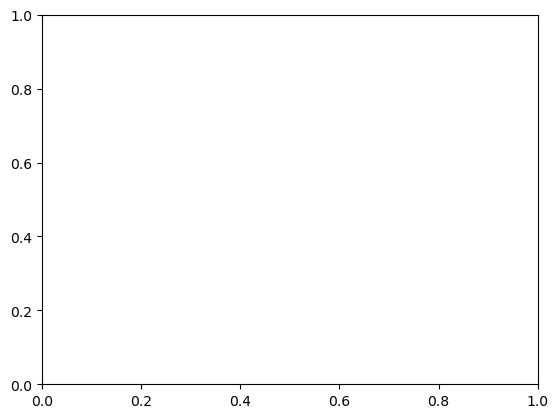

In [29]:
forests = [] # forest[0] is forests with same dataset
accuracy = []
sourced_accuracy = []

for i in range(5):
    rf1, accuracy_score, sourced_accuracy_score = function(500, seed = i, depth = 5)
    forests.append(rf1)
    accuracy.append(accuracy_score)
    sourced_accuracy.append(sourced_accuracy_score)

for i in range(10):
    depth = np.arange(10)
    plt.plot(depth, accuracy[i])
    plt.xlabel('Label Depth')
    plt.ylabel('Accuracy (R^2)')
    

([<matplotlib.axis.XTick at 0x21bec5350>,
 [Text(0, 0, '0'),
  Text(1, 0, '1'),
  Text(2, 0, '2'),
  Text(3, 0, '3'),
  Text(4, 0, '4')])

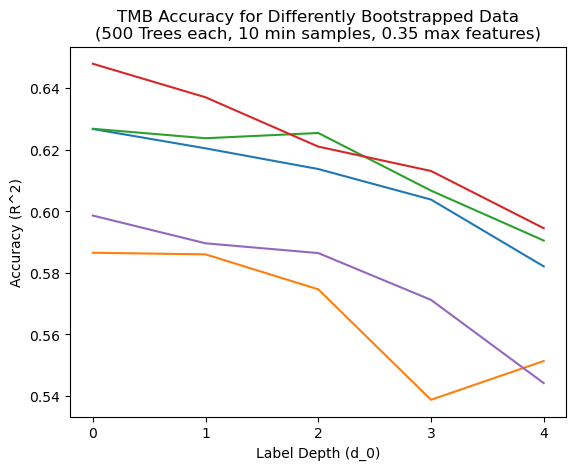

In [39]:
for i in range(5):
    depth = np.arange(5)
    plt.plot(depth, accuracy[i])
plt.xlabel('Label Depth (d_0)')
plt.ylabel('Accuracy (R^2)')
plt.title('TMB Accuracy for Differently Bootstrapped Data\n(500 Trees each, 10 min samples, 0.35 max features)')
plt.xticks([0,1,2,3,4])